#Phase 1 — Load the Dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/final_uci_drug_review_ADE_sentiment.csv")
print(df.shape)
df.head()

(161297, 15)


,uniqueID,drugName,condition,review,rating,date,usefulCount,ade_entities,ade_count,silver_label,max_confidence,max_severity,max_frequency,sentiment,sentiment_score
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,[],0,0,0.000,0,0,Neutral,0.646
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,['cranky'],1,1,0.806,0,0,Neutral,0.435
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,['brown discharge'],1,1,0.920,0,5,Neutral,0.502
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,[],0,0,0.000,0,0,Positive,0.847
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,['constipation'],1,1,0.950,1,0,Positive,0.899


#Phase 2 — Inspect the Dataset

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   uniqueID         161297 non-null  int64  
 1   drugName         161297 non-null  object 
 2   condition        159239 non-null  object 
 3   review           161297 non-null  object 
 4   rating           161297 non-null  int64  
 5   date             161297 non-null  object 
 6   usefulCount      161297 non-null  int64  
 7   ade_entities     161297 non-null  object 
 8   ade_count        161297 non-null  int64  
 9   silver_label     161297 non-null  int64  
 10  max_confidence   161297 non-null  float64
 11  max_severity     161297 non-null  int64  
 12  max_frequency    161297 non-null  int64  
 13  sentiment        161297 non-null  object 
 14  sentiment_score  161297 non-null  float64
dtypes: float64(2), int64(7), object(6)
memory usage: 18.5+ MB


In [4]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percentage": round(df.isnull().mean()*100,2)
})

missing.sort_values(
    "Missing",
    ascending=False
)

,Missing,Percentage
condition,2058,1.28
uniqueID,0,0.00
drugName,0,0.00
review,0,0.00
rating,0,0.00
date,0,0.00
usefulCount,0,0.00
ade_entities,0,0.00
ade_count,0,0.00
silver_label,0,0.00


In [5]:
df.dropna(inplace = True)

In [6]:
print(df.shape)
print(df.isnull().sum())

(159239, 15)
uniqueID           0
drugName           0
condition          0
review             0
rating             0
date               0
usefulCount        0
ade_entities       0
ade_count          0
silver_label       0
max_confidence     0
max_severity       0
max_frequency      0
sentiment          0
sentiment_score    0
dtype: int64


In [7]:
df["silver_label"].value_counts()

,count
silver_label,
1,110282
0,48957


In [8]:
df.describe()

,uniqueID,rating,usefulCount,ade_count,silver_label,max_confidence,max_severity,max_frequency,sentiment_score
count,159239.000000,159239.000000,159239.000000,159239.000000,159239.000000,159239.000000,159239.000000,159239.000000,159239.000000
mean,116032.886812,6.997406,28.186989,1.667858,0.692556,0.644849,0.619484,0.147803,0.701941
std,66961.789469,3.272545,36.521902,1.851003,0.461436,0.429560,1.463653,0.777924,0.177051
min,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.335000
25%,58237.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.542000
50%,115893.000000,8.000000,16.000000,1.000000,1.000000,0.950000,0.000000,0.000000,0.707000
75%,173863.500000,10.000000,37.000000,2.000000,1.000000,0.950000,0.000000,0.000000,0.869000
max,232291.000000,10.000000,1291.000000,31.000000,1.000000,0.971000,5.000000,5.000000,0.991000


#Phase 3 — Feature Engineering

##Step 1 — Encode Sentiment
*Since sentiment is text, convert it to numbers.*

In [9]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

df["sentiment_encoded"] = label_encoder.fit_transform(df["sentiment"])
print(dict(zip(
    label_encoder.classes_,
    label_encoder.transform(label_encoder.classes_)
)))

{'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


##Step 2 — TF-IDF Vectorization

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [11]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=5
)

In [12]:
X_text = tfidf.fit_transform(df["review"])

print(X_text.shape)

(159239, 5000)


##Step 3 — Define Feature Lists

###1. Hybrid features



In [13]:
hybrid_features = [
    "rating",
    "max_severity",
    "max_frequency"
]

###2. Sentiment features

In [14]:
sentiment_features = [
    "sentiment_encoded",
    "sentiment_score"
]

##Step 4 — Define Target

In [15]:
y = df["silver_label"]

Quick Check

In [16]:
print("Dataset shape:", df.shape)
print("TF-IDF shape:", X_text.shape)

print("\nHybrid features:")
print(df[hybrid_features].head())

print("\nSentiment features:")
print(df[sentiment_features].head())

print("\nTarget distribution:")
print(y.value_counts())

Dataset shape: (159239, 16)
TF-IDF shape: (159239, 5000)

Hybrid features:
   rating  max_severity  max_frequency
0       9             0              0
1       8             0              0
2       5             0              5
3       8             0              0
4       9             1              0

Sentiment features:
   sentiment_encoded  sentiment_score
0                  1            0.646
1                  1            0.435
2                  1            0.502
3                  2            0.847
4                  2            0.899

Target distribution:
silver_label
1    110282
0     48957
Name: count, dtype: int64


#Phase 4 — Construct the Three Feature Sets

**Feature Set A (Baseline)**
1. TF-IDF (review)

**Feature Set B**
1. TF-IDF
2. Rating
3. Max Severity
4. Max Frequency

**Feature Set C**
1. TF-IDF
2. Rating
3. Max Severity
4. Max Frequency
5. Sentiment Encoded
6. Sentiment Score


In [17]:
from scipy.sparse import hstack
from scipy.sparse import csr_matrix

In [18]:
X_A = X_text

##Feature Set B (Hybrid NLP Features)

In [19]:
X_B = hstack([
    X_text,
    csr_matrix(df[hybrid_features].values)
])

##Feature Set C (Hybrid + Sentiment)

In [20]:
all_features = hybrid_features + sentiment_features
X_C = hstack([
    X_text,
    csr_matrix(df[all_features].values)
])

In [21]:
print("Feature Set A:", X_A.shape)
print("Feature Set B:", X_B.shape)
print("Feature Set C:", X_C.shape)

Feature Set A: (159239, 5000)
Feature Set B: (159239, 5003)
Feature Set C: (159239, 5005)


#Phase 5 — Train / Validation / Test Split

70% Train
10% Validation
20% Test

We'll do it in two steps using stratified sampling.

##Step 1 — Import

In [22]:
from sklearn.model_selection import train_test_split

##Step 2 — Split off the Test Set (20%)

### 1. Feature Set A

In [23]:
XA_trainval, XA_test, y_trainval, y_test = train_test_split(
    X_A,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

###2. Feature Set B

In [24]:
XB_trainval, XB_test, _, _ = train_test_split(
    X_B,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

###3. Feature Set C

In [25]:
XC_trainval, XC_test, _, _ = train_test_split(
    X_C,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

##Step 3 — Create Validation Set

Now split the remaining 80%.
We want :
Train = 70%,
Validation = 10%

Since validation should be 10 out of the remaining 80, we use - 10 / 80 = 0.125

### 1. Feature Set A

In [26]:
XA_train, XA_val, y_train, y_val = train_test_split(
    XA_trainval,
    y_trainval,
    test_size=0.125,
    random_state=42,
    stratify=y_trainval
)

###2. Feature Set B

In [27]:
XB_train, XB_val, _, _ = train_test_split(
    XB_trainval,
    y_trainval,
    test_size=0.125,
    random_state=42,
    stratify=y_trainval
)

###3. Feature Set C

In [28]:
XC_train, XC_val, _, _ = train_test_split(
    XC_trainval,
    y_trainval,
    test_size=0.125,
    random_state=42,
    stratify=y_trainval
)

VERIFY

In [29]:
print("TRAIN :", XA_train.shape)
print("VALID :", XA_val.shape)
print("TEST  :", XA_test.shape)

TRAIN : (111467, 5000)
VALID : (15924, 5000)
TEST  : (31848, 5000)


##Step 5 — Verify Label Distribution

In [30]:
print("Train")
print(y_train.value_counts(normalize=True))

print("\nValidation")
print(y_val.value_counts(normalize=True))

print("\nTest")
print(y_test.value_counts(normalize=True))

Train
silver_label
1    0.692555
0    0.307445
Name: proportion, dtype: float64

Validation
silver_label
1    0.69254
0    0.30746
Name: proportion, dtype: float64

Test
silver_label
1    0.692571
0    0.307429
Name: proportion, dtype: float64


#Phase 6 — Linear SVM Training

In [31]:
# Import the Support Vector Machine classifier

from sklearn.svm import SVC

##Model Creation

In [32]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    C=1.0,
    random_state=42
)

# Phase 7 — Applying Train-Validation-Test on the Model

## Phase 7.1 — Feature Set A (Baseline)

### Train

In [33]:
# Train the Linear SVM model on Feature Set A

svm_model.fit(XA_train, y_train)

LinearSVC(random_state=42)

In [34]:
# Validation prediction for Feature Set A

y_val_pred_A = svm_model.predict(XA_val)

## Validation

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Validation Accuracy :", accuracy_score(y_val, y_val_pred_A))
print("Validation Precision:", precision_score(y_val, y_val_pred_A))
print("Validation Recall   :", recall_score(y_val, y_val_pred_A))
print("Validation F1-score :", f1_score(y_val, y_val_pred_A))

Validation Accuracy : 0.8210876664154735
Validation Precision: 0.8605943038532757
Validation Recall   : 0.8850199492201668
Validation F1-score : 0.8726362376503196


In [36]:
# Test Set Evaluation - Model A

test_predictions_A = svm_model.predict(XA_test)

accuracy_A = accuracy_score(y_test, test_predictions_A)
precision_A = precision_score(y_test, test_predictions_A)
recall_A = recall_score(y_test, test_predictions_A)
f1_A = f1_score(y_test, test_predictions_A)

print("Model A (TF-IDF)")
print(f"Accuracy : {accuracy_A:.4f}")
print(f"Precision: {precision_A:.4f}")
print(f"Recall   : {recall_A:.4f}")
print(f"F1 Score : {f1_A:.4f}")

Model A (TF-IDF)
Accuracy : 0.8214
Precision: 0.8618
Recall   : 0.8838
F1 Score : 0.8727


### Confusion Matrix

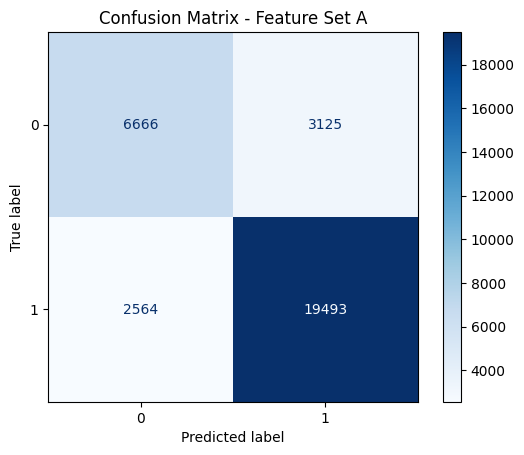

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    svm_model,
    XA_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix - Feature Set A")
plt.show()

Classification Report

In [38]:
from sklearn.metrics import classification_report

In [46]:
# Classification Report - Feature Set A Test Set

print("Classification Report - Feature Set A (Test Set)\n")

print(
    classification_report(
        y_test,
        test_predictions_A,
        target_names=["Negative", "Positive"]
    )
)

Classification Report - Feature Set A (Test Set)

              precision    recall  f1-score   support

    Negative       0.72      0.68      0.70      9791
    Positive       0.86      0.88      0.87     22057

    accuracy                           0.82     31848
   macro avg       0.79      0.78      0.79     31848
weighted avg       0.82      0.82      0.82     31848



## Feature Set B: Model Evaluation

In [40]:
from sklearn.svm import LinearSVC

# Train Linear SVM on Feature Set B
svm_B = LinearSVC(random_state=42)
svm_B.fit(XB_train, y_train)

LinearSVC(random_state=42)

In [41]:
# Predict on the validation set
y_val_pred_B = svm_B.predict(XB_val)

In [42]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Validation Accuracy :", accuracy_score(y_val, y_val_pred_B))
print("Validation Precision:", precision_score(y_val, y_val_pred_B))
print("Validation Recall   :", recall_score(y_val, y_val_pred_B))
print("Validation F1-score :", f1_score(y_val, y_val_pred_B))

Validation Accuracy : 0.8339613162521979
Validation Precision: 0.8802612481857764
Validation Recall   : 0.8799419659049692
Validation F1-score : 0.8801015780881553


In [47]:
# Test Set Evaluation - Model B

test_predictions_B = svm_B.predict(XB_test)

accuracy_B_test = accuracy_score(y_test, test_predictions_B)
precision_B_test = precision_score(y_test, test_predictions_B)
recall_B_test = recall_score(y_test, test_predictions_B)
f1_B_test = f1_score(y_test, test_predictions_B)

print("Model B (TF-IDF + Hybrid)")
print(f"Accuracy : {accuracy_B_test:.4f}")
print(f"Precision: {precision_B_test:.4f}")
print(f"Recall   : {recall_B_test:.4f}")
print(f"F1 Score : {f1_B_test:.4f}")

Model B (TF-IDF + Hybrid)
Accuracy : 0.8339
Precision: 0.8813
Recall   : 0.8785
F1 Score : 0.8799


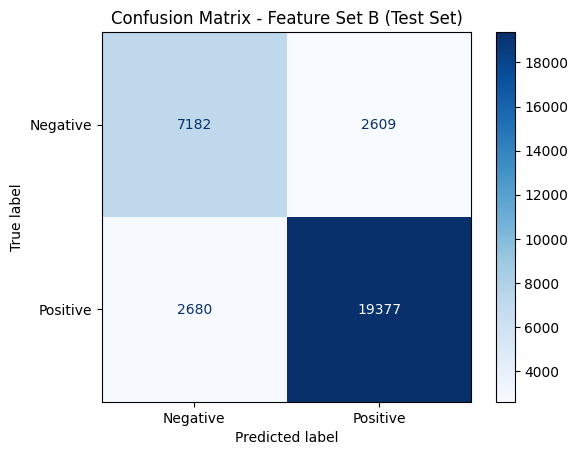

In [52]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix - Feature Set B Test Set

cm_B_test = confusion_matrix(y_test, test_predictions_B)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_B_test,
    display_labels=["Negative", "Positive"]
)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Feature Set B (Test Set)")
plt.show()

In [53]:
from sklearn.metrics import classification_report

print("Classification Report:\n")

print(classification_report(
    y_test,
    test_predictions_B,
    target_names=["Negative", "Positive"]
))

Classification Report:

              precision    recall  f1-score   support

    Negative       0.73      0.73      0.73      9791
    Positive       0.88      0.88      0.88     22057

    accuracy                           0.83     31848
   macro avg       0.80      0.81      0.81     31848
weighted avg       0.83      0.83      0.83     31848



## Feature Set C: Linear SVM Model Evaluation

In [54]:
from sklearn.svm import LinearSVC

# Train Linear SVM on Feature Set C
svm_C = LinearSVC(random_state=42)
svm_C.fit(XC_train, y_train)

LinearSVC(random_state=42)

In [55]:
# Predict on the validation set
y_val_pred_C = svm_C.predict(XC_val)

In [56]:
# Test Set Evaluation - Model C

test_predictions_C = svm_C.predict(XC_test)

accuracy_C_test = accuracy_score(y_test, test_predictions_C)
precision_C_test = precision_score(y_test, test_predictions_C)
recall_C_test = recall_score(y_test, test_predictions_C)
f1_C_test = f1_score(y_test, test_predictions_C)

print("Model C (TF-IDF + Hybrid + Sentiment)")
print(f"Accuracy : {accuracy_C_test:.4f}")
print(f"Precision: {precision_C_test:.4f}")
print(f"Recall   : {recall_C_test:.4f}")
print(f"F1 Score : {f1_C_test:.4f}")

Model C (TF-IDF + Hybrid + Sentiment)
Accuracy : 0.8341
Precision: 0.8814
Recall   : 0.8787
F1 Score : 0.8801


### Evaluation Metrics

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Validation Accuracy :", accuracy_score(y_val, y_val_pred_C))
print("Validation Precision:", precision_score(y_val, y_val_pred_C))
print("Validation Recall   :", recall_score(y_val, y_val_pred_C))
print("Validation F1-score :", f1_score(y_val, y_val_pred_C))

Validation Accuracy : 0.8333961316252197
Validation Precision: 0.8800943995643097
Validation Recall   : 0.8792165397170838
Validation F1-score : 0.8796552506237242


### Confusion Matrix

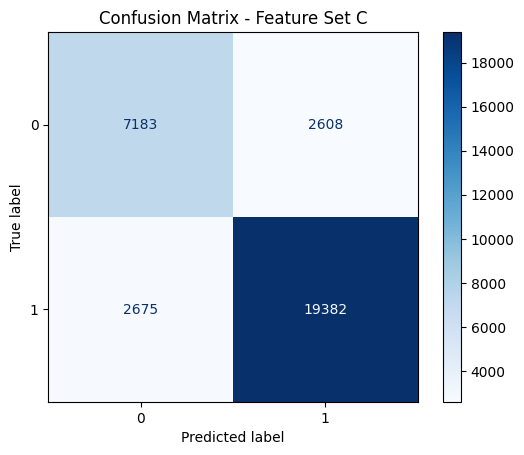

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_C = confusion_matrix(y_test, test_predictions_C)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_C)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Feature Set C")
plt.show()

### Classification Report

In [60]:
from sklearn.metrics import classification_report

print("Classification Report:\n")

print(classification_report(
    y_test,
    test_predictions_C,
    target_names=["Negative", "Positive"]
))

Classification Report:

              precision    recall  f1-score   support

    Negative       0.73      0.73      0.73      9791
    Positive       0.88      0.88      0.88     22057

    accuracy                           0.83     31848
   macro avg       0.81      0.81      0.81     31848
weighted avg       0.83      0.83      0.83     31848



In [61]:
import pandas as pd

# Final Test Set Model Comparison

results = pd.DataFrame({
    "Feature Set": [
        "A (TF-IDF)",
        "B (TF-IDF + Hybrid)",
        "C (TF-IDF + Hybrid + Sentiment)"
    ],
    "Accuracy": [
        accuracy_A,
        accuracy_B_test,
        accuracy_C_test
    ],
    "Precision": [
        precision_A,
        precision_B_test,
        precision_C_test
    ],
    "Recall": [
        recall_A,
        recall_B_test,
        recall_C_test
    ],
    "F1 Score": [
        f1_A,
        f1_B_test,
        f1_C_test
    ]
})

results = results.round(4)

print("Final Test Set Results:")
print(results)

Final Test Set Results:
                       Feature Set  Accuracy  Precision  Recall  F1 Score
0                       A (TF-IDF)    0.8214     0.8618  0.8838    0.8727
1              B (TF-IDF + Hybrid)    0.8339     0.8813  0.8785    0.8799
2  C (TF-IDF + Hybrid + Sentiment)    0.8341     0.8814  0.8787    0.8801
